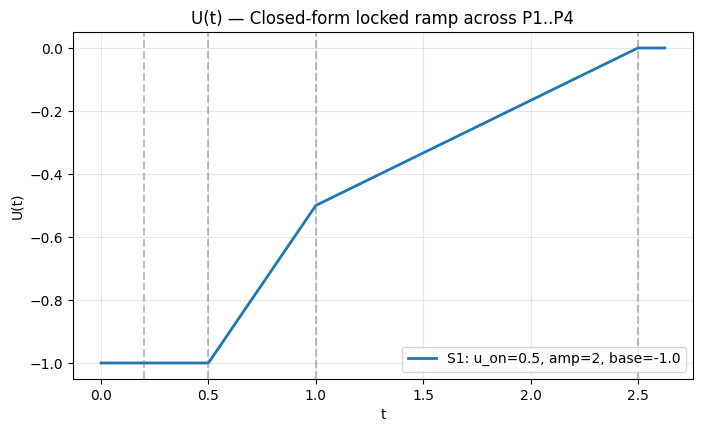

In [2]:
# Fallback: Non-widget version (no ipywidgets). 
# Defines a closed-form U(t) and plots several scenarios in a single chart.
# Uses matplotlib only, one chart, no explicit colors. Includes optional js.seval hook if available.

import numpy as np
import matplotlib.pyplot as plt

def prep_uparams(u_onset, t1, t2, t3, t4):
    a1, b1 = 0.0, t1
    a2, b2 = t1, t2
    a3, b3 = t2, t3
    a4, b4 = t3, t4

    s1 = max(u_onset, a1); d1 = b1 - s1; m1 = d1 > 0.0; w1 = (1.0 / d1) if m1 else 0.0
    s2 = max(u_onset, a2); d2 = b2 - s2; m2 = d2 > 0.0; w2 = (1.0 / d2) if m2 else 0.0
    s3 = max(u_onset, a3); d3 = b3 - s3; m3 = d3 > 0.0; w3 = (1.0 / d3) if m3 else 0.0
    s4 = max(u_onset, a4); d4 = b4 - s4; m4 = d4 > 0.0; w4 = (1.0 / d4) if m4 else 0.0

    return (s1, w1, m1, s2, w2, m2, s3, w3, m3, s4, w4, m4)

def U_locked_closedform(t, U_amp, U_base, params):
    s1, w1, m1, s2, w2, m2, s3, w3, m3, s4, w4, m4 = params
    r1 = np.clip((t - s1) * w1, 0.0, 1.0) if m1 else 0.0
    r2 = np.clip((t - s2) * w2, 0.0, 1.0) if m2 else 0.0
    r3 = np.clip((t - s3) * w3, 0.0, 1.0) if m3 else 0.0
    r4 = np.clip((t - s4) * w4, 0.0, 1.0) if m4 else 0.0
    return U_base + 0.25 * U_amp * (r1 + r2 + r3 + r4)

def plot_U_scenarios(scenarios, tmax=None, npts=1000):
    if tmax is None:
        tmax = max(s["t4"] for s in scenarios) * 1.05
    t = np.linspace(0.0, tmax, npts)

    plt.figure(figsize=(8, 4.5))
    for idx, s in enumerate(scenarios, start=1):
        params = prep_uparams(s["u_onset"], s["t1"], s["t2"], s["t3"], s["t4"])
        U = U_locked_closedform(t, s["U_amp"], s["U_base"], params)
        plt.plot(t, U, linewidth=2, label=f"S{idx}: u_on={s['u_onset']}, amp={s['U_amp']}, base={s['U_base']}")
    for s in scenarios:
        plt.axvline(s["t1"], ls='--', color='gray', alpha=0.5)
        plt.axvline(s["t2"], ls='--', color='gray', alpha=0.5)
        plt.axvline(s["t3"], ls='--', color='gray', alpha=0.5)
        plt.axvline(s["t4"], ls='--', color='gray', alpha=0.5)
    plt.xlabel("t")
    plt.ylabel("U(t)")
    plt.title("U(t) — Closed-form locked ramp across P1..P4")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # Optional js.seval log
    try:
        import js
        js.seval("console.log('U plot (non-widget) ready');")
    except Exception:
        pass

# Example scenarios (edit these dictionaries to try different values)
scenarios = [
    dict(t1=0.2, t2=0.5, t3=1.0, t4=2.5, u_onset=0.5, U_amp=2, U_base=-1.0),
    # dict(t1=0.5, t2=1.1, t3=1.5, t4=2.5, u_onset=0.5, U_amp=2, U_base=-1),
    # dict(t1=0.5, t2=1.4, t3=2.0, t4=2.5, u_onset=0.5, U_amp=2, U_base=-1),
    # dict(t1=0.7, t2=1.5, t3=2.2, t4=2.5, u_onset=0.5, U_amp=2.0, U_base=-1.0),
]

plot_U_scenarios(scenarios)

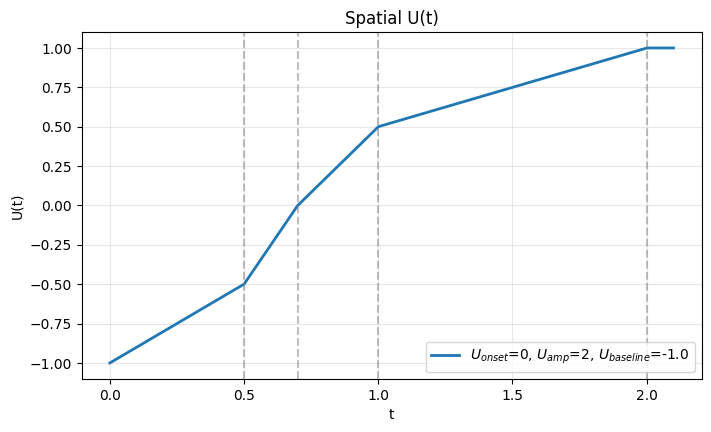

In [30]:
def prep_uparams(u_onset, t1, t2, t3, t4):
    # Segment ends
    b1, b2, b3, b4 = t1, t2, t3, t4
    # Constant offset: quarters of segments completed at u_onset
    completed = (u_onset >= b1) + (u_onset >= b2) + (u_onset >= b3) + (u_onset >= b4)
    C = 0.25 * completed
    
    # Effective starts for each segment and denominators
    a1, a2, a3, a4 = 0.0, t1, t2, t3
    s1 = max(u_onset, a1); d1 = b1 - s1; m1 = d1 > 0.0; w1 = (1.0 / d1) if m1 else 0.0
    s2 = max(u_onset, a2); d2 = b2 - s2; m2 = d2 > 0.0; w2 = (1.0 / d2) if m2 else 0.0
    s3 = max(u_onset, a3); d3 = b3 - s3; m3 = d3 > 0.0; w3 = (1.0 / d3) if m3 else 0.0
    s4 = max(u_onset, a4); d4 = b4 - s4; m4 = d4 > 0.0; w4 = (1.0 / d4) if m4 else 0.0

    return (C, s1, w1, m1, s2, w2, m2, s3, w3, m3, s4, w4, m4)

import numpy as np
import matplotlib.pyplot as plt

def U_locked_no_onset(t, U_amp, U_base, t1, t2, t3, t4):
    w1 = 1.0 / (t1 - 0.0)
    w2 = 1.0 / (t2 - t1)
    w3 = 1.0 / (t3 - t2)
    w4 = 1.0 / (t4 - t3)
    r1 = np.clip(t * w1,            0.0, 1.0)
    r2 = np.clip((t - t1) * w2,     0.0, 1.0)
    r3 = np.clip((t - t2) * w3,     0.0, 1.0)
    r4 = np.clip((t - t3) * w4,     0.0, 1.0)
    return U_base + 0.25 * U_amp * (r1 + r2 + r3 + r4)

def plot_U(t1, t2, t3, t4, U_amp, U_base, npts=1200):
    tmax = t4 * 1.05
    t = np.linspace(0.0, tmax, npts)
    U = U_locked_no_onset(t, U_amp, U_base, t1, t2, t3, t4)
    plt.figure(figsize=(8,4.5))
    plt.plot(t, U, linewidth=2)
    for x in [t1, t2, t3, t4]:
        plt.axvline(x, ls='--', linewidth=1)
    plt.xlabel("t"); plt.ylabel("U(t)")
    plt.title(f"U(t) sin onset — amp={U_amp}, base={U_base}")
    plt.grid(True, alpha=0.3)
    plt.show()
    try:
        import js; js.seval("console.log('U plot ready (no onset)');")
    except Exception:
        pass

# ejemplo
# plot_U(0.5, 1.1, 1.8, 3.0, U_amp=2.0, U_base=-0.5)


def plot_U_scenarios(scenarios, tmax=None, npts=1000):
    if tmax is None:
        tmax = max(s["t4"] for s in scenarios) * 1.05
    t = np.linspace(0.0, tmax, npts)

    plt.figure(figsize=(8, 4.5))
    for idx, s in enumerate(scenarios, start=1):
        params = prep_uparams(s["u_onset"], s["t1"], s["t2"], s["t3"], s["t4"])
        U = U_locked_closedform(t, s["U_amp"], s["U_base"], s["u_onset"], params)
        plt.plot(t, U, linewidth=2, label=f"$U_{{onset}}$={s['u_onset']}, $U_{{amp}}$={s['U_amp']}, $U_{{baseline}}$={s['U_base']}")
    for s in scenarios:
        plt.axvline(s["t1"], ls='--', color='gray', alpha=0.5)
        plt.axvline(s["t2"], ls='--', color='gray', alpha=0.5)
        plt.axvline(s["t3"], ls='--', color='gray', alpha=0.5)
        plt.axvline(s["t4"], ls='--', color='gray', alpha=0.5)
    plt.xlabel("t")
    plt.ylabel("U(t)")
    plt.title("Spatial U(t)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # Optional js.seval log
    try:
        import js
        js.seval("console.log('U plot (non-widget) ready');")
    except Exception:
        pass

# Example scenarios (edit these dictionaries to try different values)
scenarios = [
    dict(t1=0.5, t2=0.7, t3=1, t4=2., u_onset=0, U_amp=2, U_base=-1.0),
    # dict(t1=0.5, t2=1.1, t3=1.5, t4=2.5, u_onset=0.5, U_amp=2, U_base=-1),
    # dict(t1=0.5, t2=1.4, t3=2.0, t4=2.5, u_onset=0.5, U_amp=2, U_base=-1),
    # dict(t1=0.7, t2=1.5, t3=2.2, t4=2.5, u_onset=0.5, U_amp=2.0, U_base=-1.0),
]

plot_U_scenarios(scenarios)

## Julia code

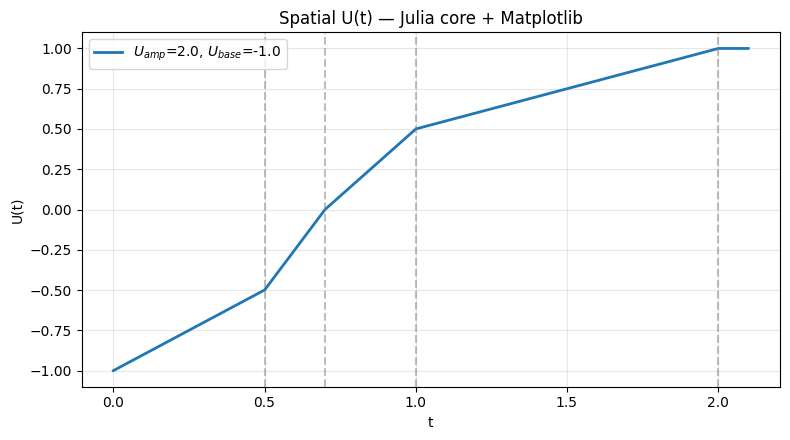

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from juliacall import Main as jl

# --- 1) Define funciones en Julia ---
jl.seval("""
function U_spatial_value(t::Float64, U_amp::Float64, U_base::Float64,
                         t1::Float64, t2::Float64, t3::Float64, t4::Float64,
                         w1::Float64, w2::Float64, w3::Float64, w4::Float64)
    r1 = clamp(t * w1,        0.0, 1.0)
    r2 = clamp((t - t1) * w2, 0.0, 1.0)
    r3 = clamp((t - t2) * w3, 0.0, 1.0)
    r4 = clamp((t - t3) * w4, 0.0, 1.0)
    return muladd(0.25 * U_amp, (r1 + r2 + r3 + r4), U_base)
end

# Vectorial: calcula U(t) para todo un vector t
function U_spatial_curve(t::AbstractVector{<:Real}, U_amp::Real, U_base::Real,
                         t1::Real,t2::Real,t3::Real,t4::Real)
    # Pesos por tramo
    w1 = 1/(t1 - 0.0)
    w2 = 1/(t2 - t1)
    w3 = 1/(t3 - t2)
    w4 = 1/(t4 - t3)
    # Broadcast en Julia (rápido y limpio)
    return U_spatial_value.(Float64.(t), float(U_amp), float(U_base),
                            float(t1), float(t2), float(t3), float(t4),
                            float(w1), float(w2), float(w3), float(w4))
end
""")

# --- 2) Wrapper Python ---
def U_locked_closedform_vec(t, U_amp, U_base, t1, t2, t3, t4):
    tj = jl.Vector(t)  # numpy -> Julia Vector
    Uj = jl.U_spatial_curve(tj, U_amp, U_base, t1, t2, t3, t4)
    return np.array(Uj)  # Julia -> numpy

def plot_U_scenarios(scenarios, tmax=None, npts=1000):
    if tmax is None:
        tmax = max(s["t4"] for s in scenarios) * 1.05
    t = np.linspace(0.0, tmax, npts)

    plt.figure(figsize=(8, 4.5))
    for s in scenarios:
        # sanity checks para evitar divisiones por cero o orden incorrecto
        assert s["t1"] > 0 and s["t2"] > s["t1"] and s["t3"] > s["t2"] and s["t4"] > s["t3"], \
            "Se requiere 0 < t1 < t2 < t3 < t4"

        U = U_locked_closedform_vec(
            t, s["U_amp"], s["U_base"], s["t1"], s["t2"], s["t3"], s["t4"]
        )
        label = fr"$U_{{amp}}$={s['U_amp']}, $U_{{base}}$={s['U_base']}"
        plt.plot(t, U, lw=2, label=label)

        for x in [s["t1"], s["t2"], s["t3"], s["t4"]]:
            plt.axvline(x, ls='--', color='gray', alpha=0.5)

    plt.xlabel("t"); plt.ylabel("U(t)")
    plt.title("Spatial U(t) — Julia core + Matplotlib")
    plt.grid(True, alpha=0.3); plt.legend()
    plt.tight_layout(); plt.show()

# --- 3) Ejemplo ---
scenarios = [
    dict(t1=0.5, t2=0.7, t3=1.0, t4=2.0, U_amp=2.0, U_base=-1.0),
]
plot_U_scenarios(scenarios)